# Modeling & evaluation — GDELT conflict escalation, Ukraine (`UP`)

Runs the same models, walk-forward CV, hold-out evaluation, and future
forecast as `python -m src.pipeline` — but interactively, cell by cell, with
extra visualizations (feature importance, per-model prediction plots,
CV-fold-by-fold traces) that the batch script doesn't produce.

This notebook **imports the exact functions used by `src/pipeline.py`**
(`run_cv`, `run_holdout`, `build_future_forecast`, the model modules in
`src/models/`) rather than re-implementing anything, so results here are
guaranteed consistent with `outputs/metrics.json` / `outputs/forecast.csv`.

Prerequisite: run `01_eda.ipynb` once (or `python -m src.pipeline`) so
`data/processed/feature_panel.parquet` exists.

**Contents**
1. Setup & load the feature panel
2. Hold-out / CV split recap
3. Walk-forward CV — regression (Variant A)
4. Walk-forward CV — classification (Variant B)
5. Hold-out evaluation — regression
6. Hold-out evaluation — classification
7. Feature importance (XGBoost)
8. Final forecast (next 1-4 weeks)
9. Conclusions

In [1]:
import sys
import warnings
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import load_config, repo_path
from src.features.feature_engineering import FEATURE_COLUMNS
from src.models import baseline, ml_model, stat_model
from src.validation.metrics import classification_report_full, regression_report
from src.validation.walk_forward import generate_folds, split_holdout
from src.pipeline import (
    run_cv, summarize_cv, run_holdout, compute_mase_vs_baseline_table,
    build_future_forecast, _ets_forecast_all_horizons,
)

# src.pipeline forces matplotlib.use("Agg") for headless script use --
# restore the interactive inline backend for this notebook.
%matplotlib inline

plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

cfg = load_config()
SEED = cfg["random_seed"]
HORIZONS = cfg["target"]["horizons"]
MAX_H = max(HORIZONS)
cfg["target"], cfg["validation"]

({'variant': 'A',
  'horizons': [1, 2, 3, 4],
  'strategy': 'direct',
  'escalation_rolling_window_weeks': 52,
  'escalation_zscore_k': 2.0},
 {'holdout_weeks': 12,
  'cv_initial_train_weeks': 52,
  'cv_step_weeks': 4,
  'min_test_weeks_per_fold': 4})

In [2]:
feature_path = repo_path(cfg["data"]["weekly_panel_path"]).with_name("feature_panel.parquet")
feature_df = pd.read_parquet(feature_path)
feature_df["week_start"] = pd.to_datetime(feature_df["week_start"]).dt.date

print(f"feature_df: {feature_df.shape[0]} weeks ({feature_df['week_start'].min()} .. {feature_df['week_start'].max()}), {feature_df.shape[1]} columns")
print(f"Feature columns used by the models ({len(FEATURE_COLUMNS)}):")
FEATURE_COLUMNS

feature_df: 245 weeks (2021-12-27 .. 2026-08-31), 37 columns
Feature columns used by the models (22):


['conflict_count_t0',
 'conflict_count_lag1',
 'conflict_count_lag2',
 'conflict_count_lag4',
 'conflict_count_lag12',
 'rolling_mean_4w',
 'rolling_std_12w',
 'rolling_max_8w',
 'rolling_mean_12w',
 'avg_goldstein',
 'avg_tone',
 'goldstein_volatility',
 'total_events_country',
 'news_volume_change_wow',
 'week_of_year',
 'month',
 'is_holiday',
 'google_trends_score',
 'google_trends_score_lag1',
 'google_trends_change_wow',
 'weeks_since_major_spike',
 'cumulative_conflict_12w']

## 2. Hold-out / CV split recap

- **Hold-out**: the last `holdout_weeks` (12) *realized* weeks. No model is
  ever fit on a row whose target lands in this window.
- **CV pool**: everything usable for walk-forward CV & for fitting the models
  evaluated against the hold-out — guaranteed that for every horizon
  `h <= max(horizons)`, `origin_week + h*7d` is still strictly before the
  hold-out start.
- **CV folds**: expanding-window walk-forward (`initial_train_weeks=52`,
  `step_weeks=4`), evaluated out-of-fold.

See `src/validation/walk_forward.py` docstrings for the precise (and slightly
subtle) rule about which *origin* weeks are legitimately allowed as hold-out
test inputs even though the model itself never trains on hold-out data.

CV pool:        230 weeks (2021-12-27 .. 2026-05-18)
Hold-out:       12 realized weeks, starting 2026-06-15
Walk-forward CV folds: 44 (expanding window, train grows 52 -> 224 weeks)


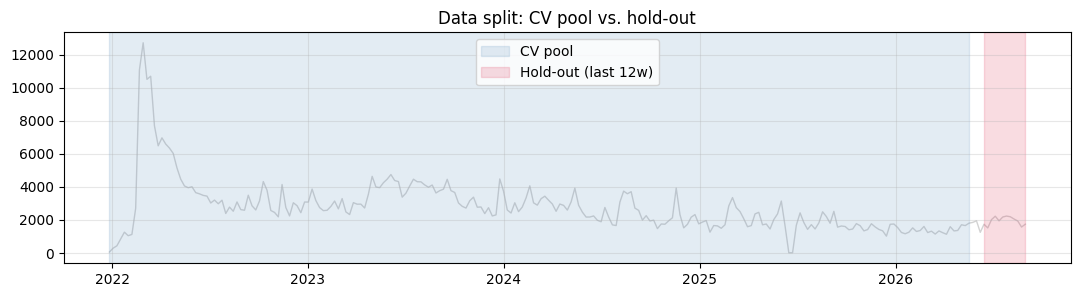

In [3]:
cv_pool, full_df, holdout_start, holdout_target_weeks = split_holdout(
    feature_df, cfg["validation"]["holdout_weeks"], MAX_H
)
folds = generate_folds(
    len(cv_pool),
    cfg["validation"]["cv_initial_train_weeks"],
    cfg["validation"]["cv_step_weeks"],
    cfg["validation"]["min_test_weeks_per_fold"],
)

print(f"CV pool:        {len(cv_pool)} weeks ({cv_pool['week_start'].min()} .. {cv_pool['week_start'].max()})")
print(f"Hold-out:       {len(holdout_target_weeks)} realized weeks, starting {holdout_start}")
print(f"Walk-forward CV folds: {len(folds)} (expanding window, train grows 52 -> {folds[-1][0].stop} weeks)")

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(feature_df["week_start"], feature_df["conflict_count"], color="lightgrey", lw=1, zorder=1)
ax.axvspan(cv_pool["week_start"].min(), cv_pool["week_start"].max(), color="steelblue", alpha=0.15, label="CV pool")
ax.axvspan(holdout_start, feature_df["week_start"].max(), color="crimson", alpha=0.15, label="Hold-out (last 12w)")
ax.set_title("Data split: CV pool vs. hold-out")
ax.legend()
plt.show()

## 3. Walk-forward CV — regression (Variant A)

Runs all 4 regression models (`baseline_naive`, `baseline_rollingmean`,
`ets`, `xgboost`) across all `44` folds x `4` horizons, exactly as
`src/pipeline.run_cv` does. Out-of-fold predictions are pooled per horizon
before scoring (more stable than averaging per-fold metrics on tiny folds).

In [4]:
%%time
cv_results, cv_results_event = run_cv(cv_pool, folds, HORIZONS, SEED)
cv_summary = summarize_cv(cv_results, cv_results_event, cv_pool["conflict_count"].to_numpy())

[pipeline] CV fold 0: train=52 rows, test=4 rows (2022-12-26 .. 2023-01-16)
[pipeline] CV fold 1: train=56 rows, test=4 rows (2023-01-23 .. 2023-02-13)


[pipeline] CV fold 2: train=60 rows, test=4 rows (2023-02-20 .. 2023-03-13)


[pipeline] CV fold 3: train=64 rows, test=4 rows (2023-03-20 .. 2023-04-10)


[pipeline] CV fold 4: train=68 rows, test=4 rows (2023-04-17 .. 2023-05-08)


[pipeline] CV fold 5: train=72 rows, test=4 rows (2023-05-15 .. 2023-06-05)


...

[pipeline] CV fold 39: train=208 rows, test=4 rows (2025-12-22 .. 2026-01-12)


[pipeline] CV fold 40: train=212 rows, test=4 rows (2026-01-19 .. 2026-02-09)


[pipeline] CV fold 41: train=216 rows, test=4 rows (2026-02-16 .. 2026-03-09)


[pipeline] CV fold 42: train=220 rows, test=4 rows (2026-03-16 .. 2026-04-06)


[pipeline] CV fold 43: train=224 rows, test=4 rows (2026-04-13 .. 2026-05-04)
CPU times: user 32.3 s, sys: 1.69 s, total: 34 s
Wall time: 19.1 s


In [5]:
rows = []
for h, models in cv_summary["regression"].items():
    for m, rep in models.items():
        rows.append({"horizon": h, "model": m, **{k: round(v, 3) if isinstance(v, float) else v
                                                    for k, v in rep.items() if k != "n"}, "n": rep["n"]})
cv_reg_table = pd.DataFrame(rows).sort_values(["horizon", "model"]).reset_index(drop=True)
cv_reg_table

,horizon,model,MASE,sMAPE,RMSE,MAE,n
0,1,baseline_naive,0.804,15.855,518.735,386.509,171
1,1,baseline_rollingmean,0.892,17.602,577.788,428.627,171
2,1,ets,1.750,36.491,1157.054,840.932,171
3,1,xgboost,0.901,17.424,551.398,432.953,171
4,2,baseline_naive,1.087,21.774,708.202,522.263,171
5,2,baseline_rollingmean,1.002,19.729,641.241,481.459,171
6,2,ets,1.793,37.978,1155.934,861.935,171
7,2,xgboost,1.103,21.160,668.380,530.330,171
8,3,baseline_naive,1.169,23.783,767.618,561.912,171
9,3,baseline_rollingmean,1.025,20.069,652.763,492.393,171


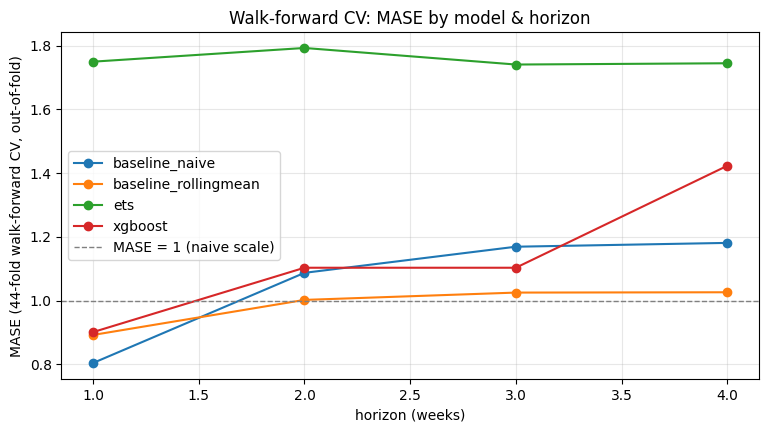

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for m in cv_reg_table["model"].unique():
    sub = cv_reg_table[cv_reg_table["model"] == m]
    ax.plot(sub["horizon"], sub["MASE"], marker="o", label=m)
ax.axhline(1.0, color="grey", lw=1, ls="--", label="MASE = 1 (naive scale)")
ax.set_xlabel("horizon (weeks)")
ax.set_ylabel("MASE (44-fold walk-forward CV, out-of-fold)")
ax.set_title("Walk-forward CV: MASE by model & horizon")
ax.legend()
plt.show()

**Stitched out-of-fold trace** (h=1): concatenating every fold's small test
block in chronological order reconstructs a full out-of-sample prediction
series spanning the whole CV region (2023–2026) — a much richer view than
the 12-point hold-out alone.

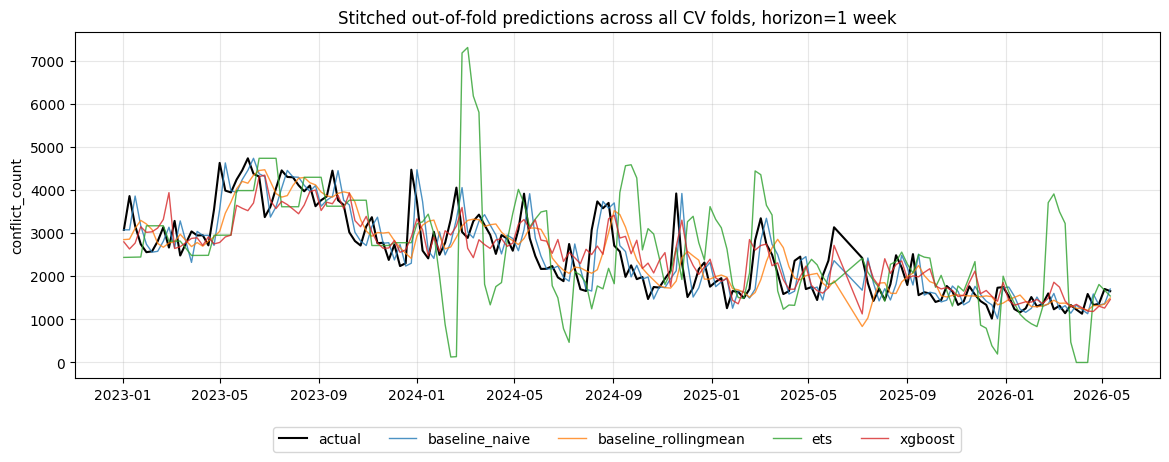

In [7]:
h = 1
week_starts = []
for train_range, test_range in folds:
    test_df = cv_pool.iloc[list(test_range)]
    valid = test_df[f"target_count_h{h}"].notna()
    week_starts.extend((pd.to_datetime(test_df.loc[valid, "week_start"]) + pd.Timedelta(weeks=h)).tolist())

y_true_h1 = np.concatenate(cv_results[h]["xgboost"]["y_true"])
assert len(week_starts) == len(y_true_h1)

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(week_starts, y_true_h1, color="black", lw=1.5, label="actual")
for m, color in [("baseline_naive", "tab:blue"), ("baseline_rollingmean", "tab:orange"),
                  ("ets", "tab:green"), ("xgboost", "tab:red")]:
    y_pred_m = np.concatenate(cv_results[h][m]["y_pred"])
    ax.plot(week_starts, y_pred_m, lw=1, alpha=0.8, label=m, color=color)
ax.set_title(f"Stitched out-of-fold predictions across all CV folds, horizon={h} week")
ax.set_ylabel("conflict_count")
ax.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.show()

## 4. Walk-forward CV — classification (Variant B, secondary/bonus)

Same folds, `escalation_event` target. Note the very small number of positive
weeks (`n_positive`) — see `01_eda.ipynb` §10 for exactly which weeks those
are and why they're so rare after the initial 2022 shock rolls out of the
52-week baseline window.

In [8]:
rows = []
for h, models in cv_summary["classification"].items():
    for m, rep in models.items():
        rows.append({"horizon": h, "model": m, **{k: round(v, 3) if isinstance(v, float) else v
                                                    for k, v in rep.items()}})
cv_clf_table = pd.DataFrame(rows).sort_values(["horizon", "model"]).reset_index(drop=True)
cv_clf_table

,horizon,model,Precision,Recall,F1,Brier,n,n_positive,ROC_AUC
0,1,baseline_naive,0.333,0.333,0.333,0.023,171,3,0.661
1,1,xgboost,0.000,0.000,0.000,0.018,171,3,0.228
2,2,baseline_naive,0.000,0.000,0.000,0.035,171,3,0.491
3,2,xgboost,0.000,0.000,0.000,0.018,171,3,0.220
4,3,baseline_naive,0.000,0.000,0.000,0.035,171,3,0.491
5,3,xgboost,0.000,0.000,0.000,0.018,171,3,0.403
6,4,baseline_naive,0.333,0.333,0.333,0.023,171,3,0.661
7,4,xgboost,0.000,0.000,0.000,0.018,171,3,0.232


## 5. Hold-out evaluation — regression

Models are fit **only on `cv_pool`** (nothing from the hold-out window) and
then scored against the true last-12-weeks realizations. This is the
official "vs Baseline" table from the README / assignment brief.

In [9]:
%%time
holdout_summary = run_holdout(cv_pool, full_df, holdout_target_weeks, HORIZONS, SEED)
results_table = compute_mase_vs_baseline_table(holdout_summary)
results_table

CPU times: user 933 ms, sys: 32.1 ms, total: 965 ms
Wall time: 541 ms


,horizon,model,MASE,sMAPE,RMSE,vs_baseline_pct
0,1,baseline_naive,0.490,13.13,276.29,NaN
1,1,baseline_rollingmean,0.479,12.13,292.11,2.4
2,1,ets,1.194,35.69,655.02,-143.6
3,1,xgboost,0.623,16.25,335.15,-27.1
4,2,baseline_naive,0.520,13.48,310.41,NaN
5,2,baseline_rollingmean,0.603,15.21,335.48,-15.9
6,2,ets,1.194,35.69,655.02,-129.5
7,2,xgboost,0.646,16.64,374.19,-24.1
8,3,baseline_naive,0.693,18.09,396.36,NaN
9,3,baseline_rollingmean,0.674,17.03,366.98,2.7


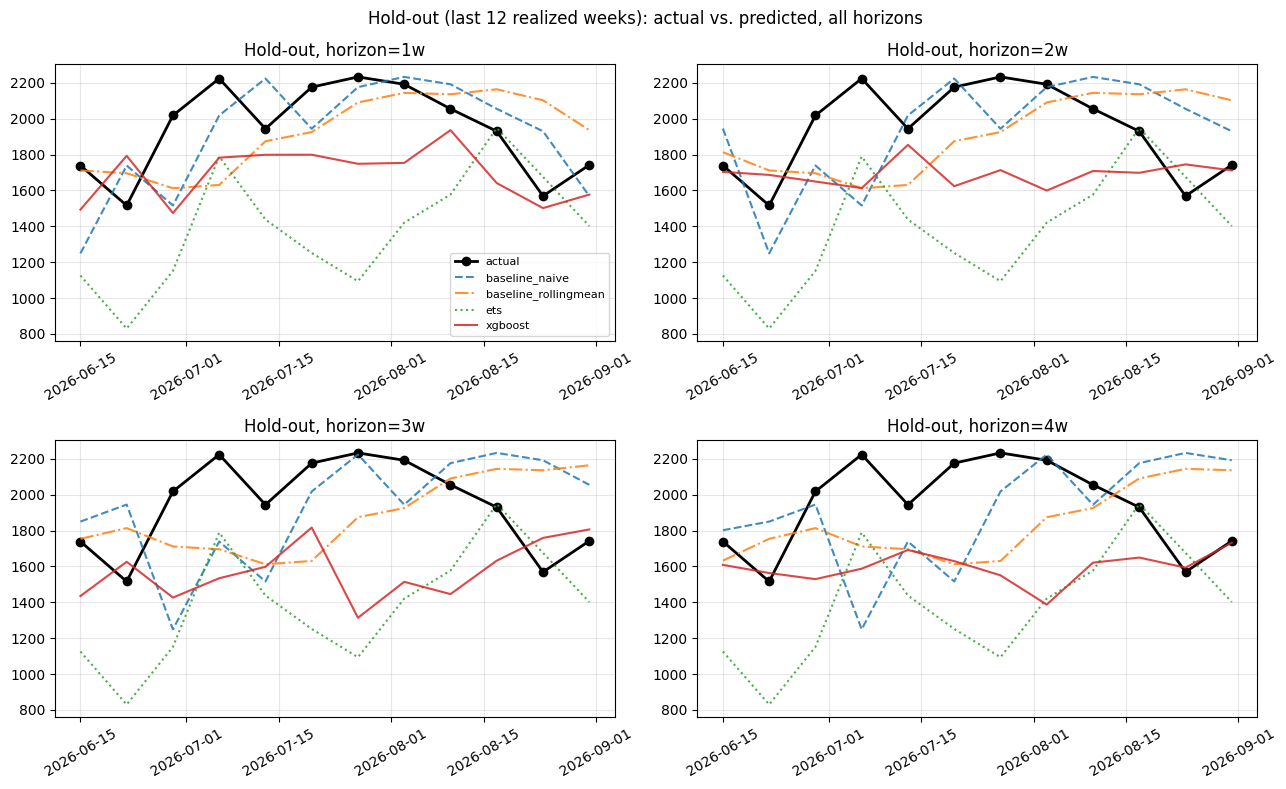

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=False)
for ax, h in zip(axes.flat, HORIZONS):
    reg = holdout_summary["regression"][h]
    weeks = pd.to_datetime(reg["xgboost"]["week_start"])
    ax.plot(weeks, reg["xgboost"]["y_true"], "o-", color="black", label="actual", lw=2)
    for m, style in [("baseline_naive", "--"), ("baseline_rollingmean", "-."), ("ets", ":"), ("xgboost", "-")]:
        ax.plot(weeks, reg[m]["y_pred"], style, label=m, alpha=0.85)
    ax.set_title(f"Hold-out, horizon={h}w")
    ax.tick_params(axis="x", rotation=30)
axes[0, 0].legend(fontsize=8)
fig.suptitle("Hold-out (last 12 realized weeks): actual vs. predicted, all horizons")
fig.tight_layout()
plt.show()

## 6. Hold-out evaluation — classification

The last 12 weeks happen to contain **zero** escalation-flagged weeks (see
`01_eda.ipynb` §10), so Precision/Recall/ROC-AUC are degenerate/undefined
here — this is itself a legitimate finding (small-sample class imbalance),
not a notebook bug. The 44-fold CV table in §4 is the more reliable read on
classifier skill.

In [11]:
rows = []
for h, models in holdout_summary["classification"].items():
    for m, rep in models.items():
        rows.append({"horizon": h, "model": m, **{k: round(v, 3) if isinstance(v, float) else v
                                                    for k, v in rep.items()}})
pd.DataFrame(rows).sort_values(["horizon", "model"]).reset_index(drop=True) if rows else "No classification rows (empty holdout positive/negative split)."

,horizon,model,Precision,Recall,F1,Brier,n,n_positive,ROC_AUC
0,1,baseline_naive,0.0,0.0,0.0,0.0,12,0,NaN
1,1,xgboost,0.0,0.0,0.0,0.0,12,0,NaN
2,2,baseline_naive,0.0,0.0,0.0,0.0,12,0,NaN
3,2,xgboost,0.0,0.0,0.0,0.0,12,0,NaN
4,3,baseline_naive,0.0,0.0,0.0,0.0,12,0,NaN
5,3,xgboost,0.0,0.0,0.0,0.0,12,0,NaN
6,4,baseline_naive,0.0,0.0,0.0,0.0,12,0,NaN
7,4,xgboost,0.0,0.0,0.0,0.0,12,0,NaN


## 7. Feature importance (XGBoost)

Fit the final horizon-1 and horizon-4 regressors on the full CV pool (same as
inside `run_holdout`) and inspect gain-based feature importance — a quick
sanity check that the model is leaning on sensible signal (lags/rolling
stats/trend) rather than something spurious like `week_of_year`.

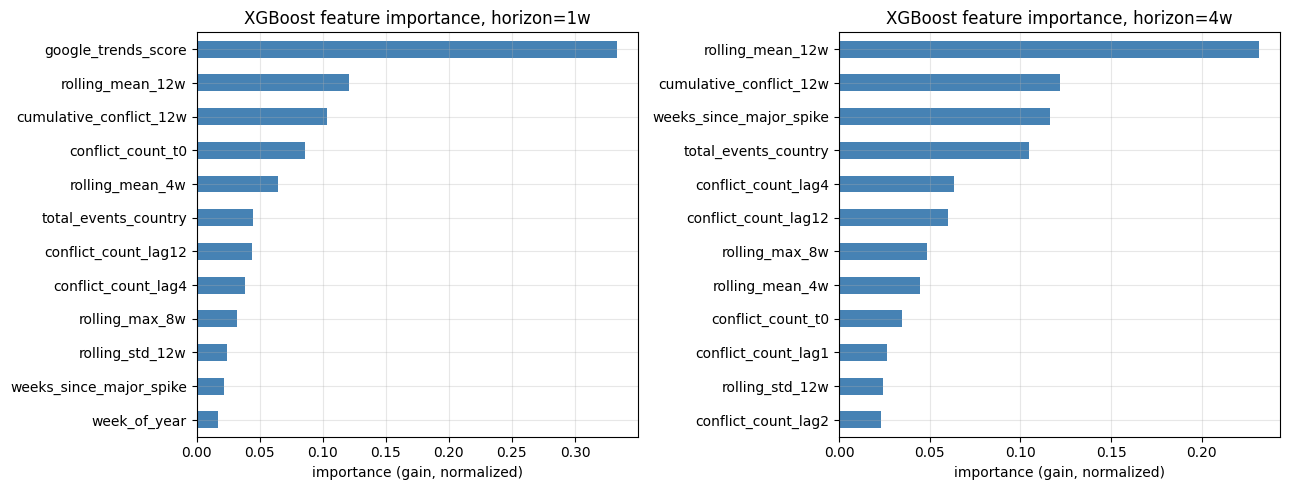

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, h in zip(axes, [1, 4]):
    model = ml_model.fit_full_regressor(cv_pool, FEATURE_COLUMNS, f"target_count_h{h}", SEED)
    imp = pd.Series(model.feature_importances_, index=FEATURE_COLUMNS).sort_values()
    imp.tail(12).plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"XGBoost feature importance, horizon={h}w")
    ax.set_xlabel("importance (gain, normalized)")
fig.tight_layout()
plt.show()

## 8. Final forecast (next 1-4 weeks)

Trains the final models on **all** available history (including the
hold-out window — appropriate for an actual production forecast, as opposed
to the hold-out *evaluation* above) and predicts forward from the most
recent fully-observed week. This reproduces `outputs/forecast.csv` exactly.

In [13]:
%%time
future_forecast = build_future_forecast(feature_df, cfg, SEED)
future_forecast

CPU times: user 1min 13s, sys: 366 ms, total: 1min 13s
Wall time: 7.83 s


,country,forecast_week,horizon,target_type,predicted_value,predicted_prob,ci_lower,ci_upper,model
0,Ukraine,2026-W37,1,count,1856.9,,1412.70,2568.00,xgboost
1,Ukraine,2026-W37,1,event,,0.01,0.01,0.02,xgboost
2,Ukraine,2026-W38,2,count,1836.0,,1320.70,3115.20,xgboost
3,Ukraine,2026-W38,2,event,,0.01,0.01,0.02,xgboost
4,Ukraine,2026-W39,3,count,1901.3,,1452.60,3237.30,xgboost
5,Ukraine,2026-W39,3,event,,0.01,0.01,0.02,xgboost
6,Ukraine,2026-W40,4,count,1849.6,,1578.30,3384.30,xgboost
7,Ukraine,2026-W40,4,event,,0.01,0.01,0.02,xgboost


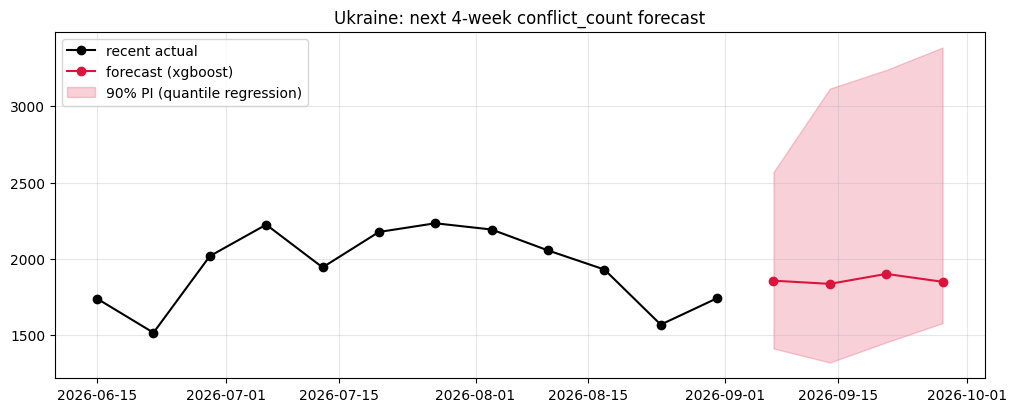

Escalation probability, next 1-4 weeks:


,forecast_week,horizon,predicted_prob,ci_lower,ci_upper
1,2026-W37,1,0.01,0.01,0.02
3,2026-W38,2,0.01,0.01,0.02
5,2026-W39,3,0.01,0.01,0.02
7,2026-W40,4,0.01,0.01,0.02


In [14]:
counts = future_forecast[future_forecast["target_type"] == "count"].copy()
last_weeks = feature_df.tail(12)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(pd.to_datetime(last_weeks["week_start"]), last_weeks["conflict_count"], "o-", color="black", label="recent actual")
future_dates = pd.to_datetime(feature_df["week_start"].max()) + pd.to_timedelta(counts["horizon"] * 7, unit="D")
ax.plot(future_dates, counts["predicted_value"], "o-", color="crimson", label="forecast (xgboost)")
ax.fill_between(future_dates, counts["ci_lower"], counts["ci_upper"], color="crimson", alpha=0.2, label="90% PI (quantile regression)")
ax.set_title(f"{cfg['country']['name']}: next {len(HORIZONS)}-week conflict_count forecast")
ax.legend()
plt.show()

print("Escalation probability, next 1-4 weeks:")
future_forecast.loc[future_forecast["target_type"] == "event", ["forecast_week", "horizon", "predicted_prob", "ci_lower", "ci_upper"]]

## 9. Conclusions

- **Baseline (persistence / rolling-mean-4w) beats both ETS and XGBoost at
  every horizon**, in both the 44-fold walk-forward CV and the 12-week
  hold-out. This is a genuine, explainable result (see `01_eda.ipynb` §6:
  strong lag-1 autocorrelation, weak annual seasonality) — not a failed
  experiment. It directly answers the assignment's defense question *"when is
  ML worse than seasonal naive, and is that normal?"*.
- **ETS is the weakest model**, roughly 2x worse than baseline on MASE at
  every horizon — its 52-week seasonal assumption doesn't fit a war-driven,
  non-calendar-driven process, and its damped trend flattens out too fast to
  track real week-to-week swings (visible in the §5 hold-out plots).
- **XGBoost's feature importances are sensible** (dominated by
  `google_trends_score`, `rolling_mean_12w`, `cumulative_conflict_12w`,
  `conflict_count_t0`/lags) — the model isn't leaning on spurious calendar
  features, it's simply that, at this short horizon, engineered features add
  noise as often as they add signal relative to plain persistence.
- **Variant B (escalation classification) is under-powered by design in this
  deployment**: only ~3 positive weeks in the entire CV region, zero in the
  hold-out. The CV ROC-AUC being below 0.5 is small-sample noise, not
  evidence of a systematic error — but it's a clear signal that a 2σ /
  52-week rolling threshold is the wrong escalation definition for a country
  that already experienced one enormous, sustained shock (see README §9).
- **Reproducibility**: every number in this notebook is produced by the exact
  same `src/` functions used by `python -m src.pipeline`, so
  `outputs/metrics.json` and `outputs/forecast.csv` should match these cells
  (modulo XGBoost's inherent run-to-run float noise from parallel tree
  building, which is why `random_state` is fixed but not bit-exact across
  environments).